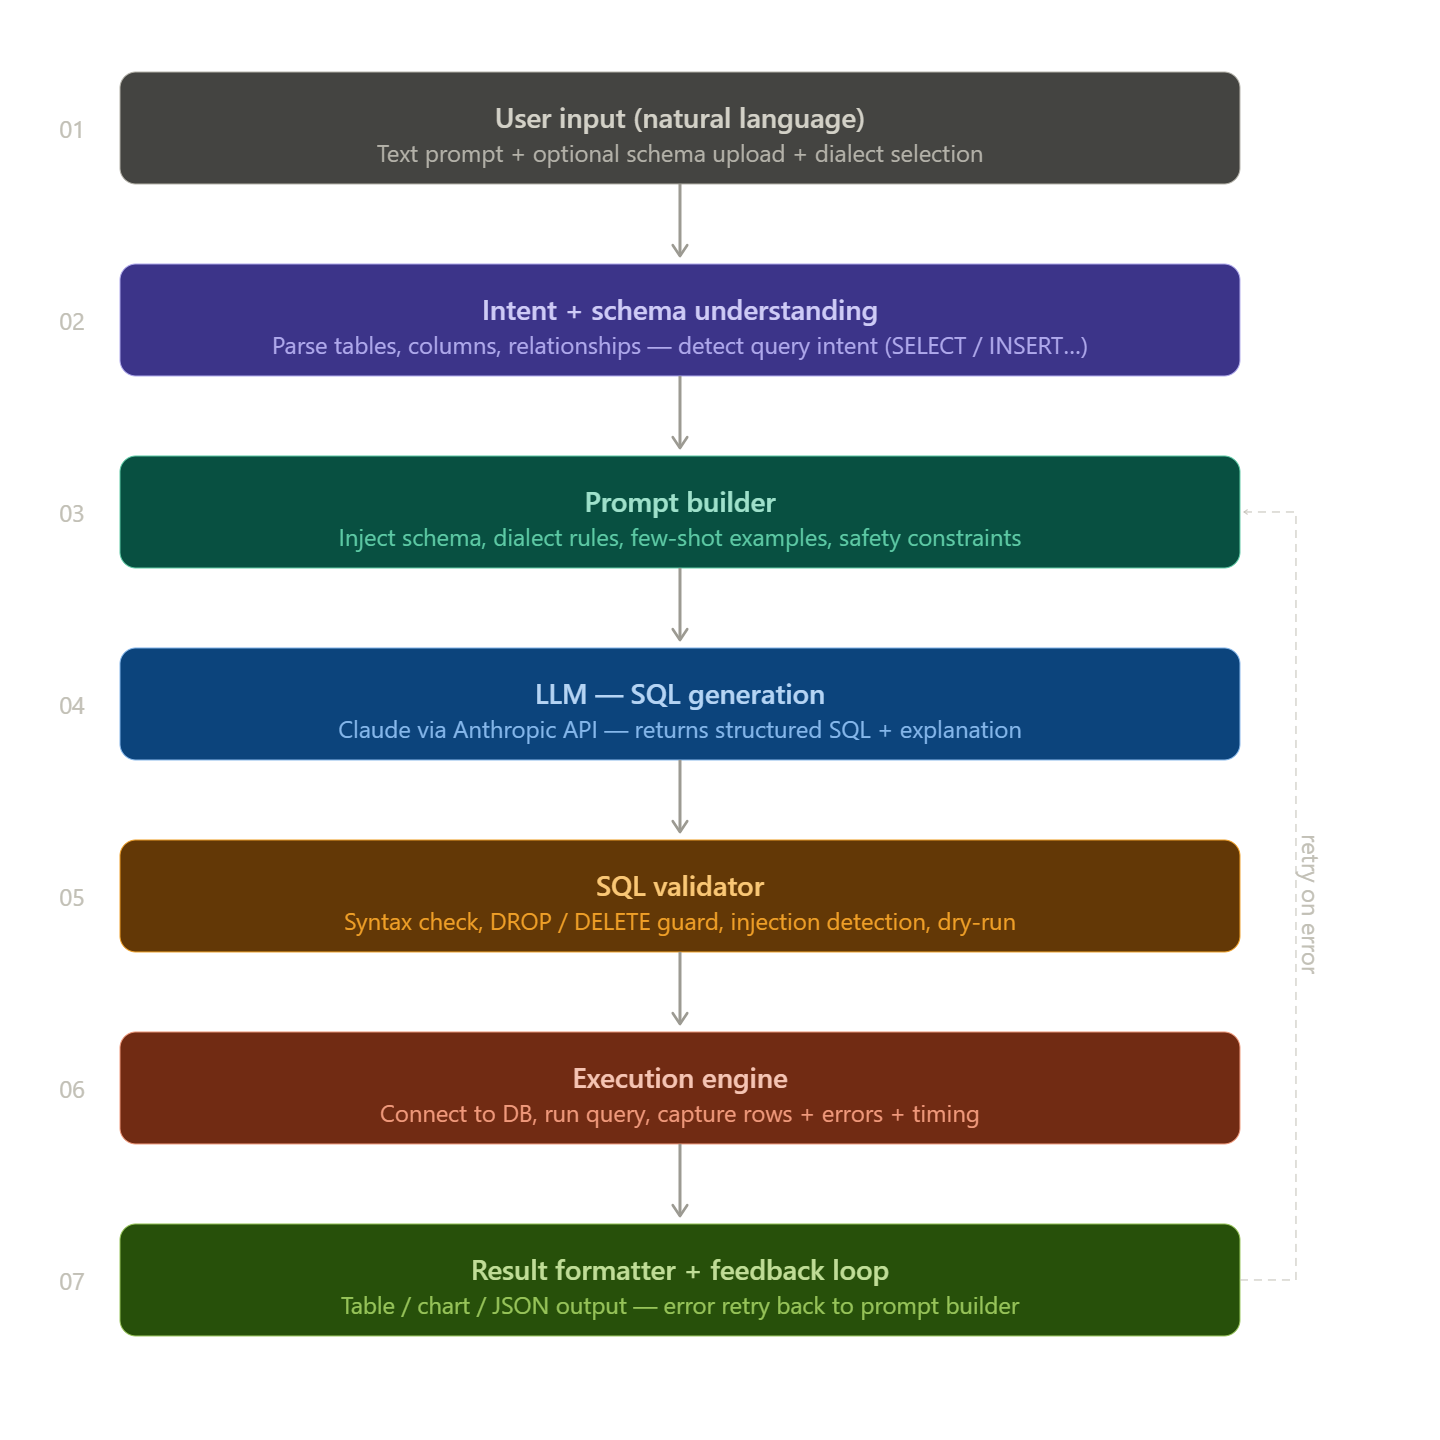

Solid architecture. Let me visualize it clearly and then break down exactly how to build each layer.Click any layer to dive deeper. Here's how to build each one:

---

**Layer 1 — User input**
A simple frontend form. Textarea for the natural language prompt, a schema editor (paste `CREATE TABLE` statements or column definitions), and a dialect dropdown. Built in React or plain HTML.

**Layer 2 — Intent + schema understanding**
Parse the user's schema string into a structured object (tables → columns → types). Detect the likely query type from the prompt (SELECT, aggregate, JOIN, INSERT) using keyword matching or a lightweight pre-pass LLM call. This structured context feeds the next layer.

**Layer 3 — Prompt builder**
The most important layer. Constructs the final system prompt dynamically by injecting the parsed schema, the selected dialect's quirks (e.g. `LIMIT` vs `TOP`), few-shot examples, and hard rules like "never use `SELECT *`" or "always alias subqueries". A well-engineered prompt here directly controls output quality.

**Layer 4 — LLM**
One API call to Claude (`claude-sonnet-4-20250514`). Ask it to return JSON: `{ "sql": "...", "explanation": "...", "warnings": [] }`. This makes the response machine-readable for the next layer.

**Layer 5 — SQL validator**
Before anything touches the database, run the SQL through a parser. Libraries like `node-sql-parser` (Node.js) or `sqlglot` (Python) can do AST-level checks. Block `DROP`, `TRUNCATE`, `DELETE` without a `WHERE`, and anything that looks like injection. Optionally use `EXPLAIN` as a dry-run.

**Layer 6 — Execution engine**
Connect to the actual database (`pg`, `mysql2`, `better-sqlite3`, etc.). Run the validated query, capture the result rows, error messages, row count, and execution time. This layer should have a hard row limit (e.g. max 500 rows returned).

**Layer 7 — Result formatter + feedback loop**
Render results as a table, chart, or raw JSON depending on the shape of the data. If execution fails, pass the error message back to the prompt builder and retry automatically — "the query failed with: column X does not exist, please fix it."

---

Want me to start building out any specific layer as code? I'd recommend starting with layers 3 + 4 (prompt builder + LLM) since that's the core, then adding the validator.

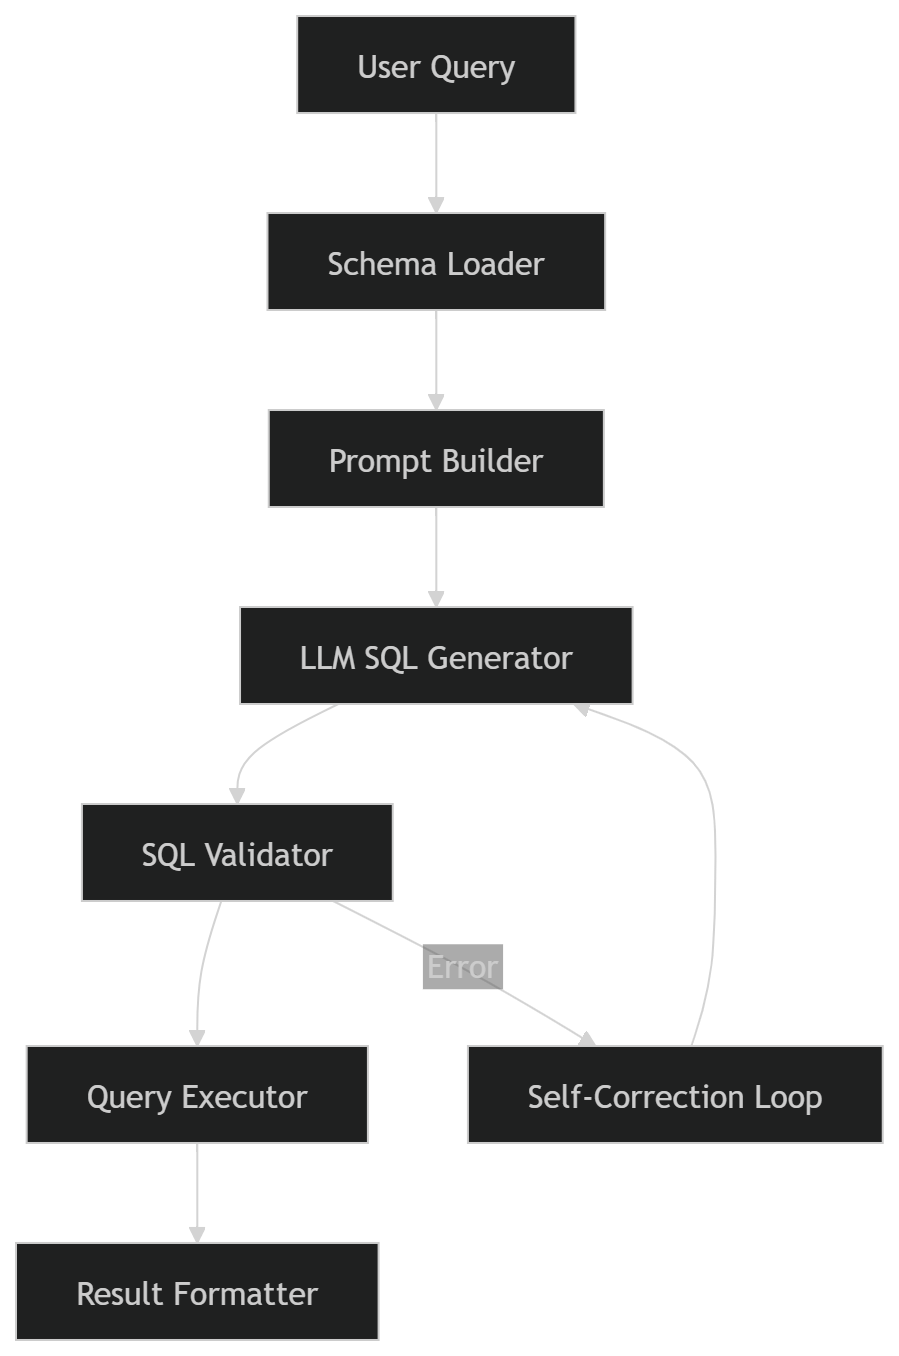


---

# 🧠 AI SQL Generator — Short Phases

## **Phase 1: Basic Generation (MVP)**

👉 Input → LLM → SQL

* Hardcoded schema
* Just generate SQL

---

## **Phase 2: Schema Awareness**

👉 Add database understanding

* Extract schema dynamically
* Pass schema into prompt

---

## **Phase 3: Validation & Safety**

👉 Make it safe

* Block harmful queries (`DROP`, `DELETE`)
* Basic SQL validation

---

## **Phase 4: Execution + Feedback**

👉 Make it intelligent

* Execute SQL
* If error → send back to LLM → fix

---

## **Phase 5: Evaluation**

👉 Measure quality

* Test dataset
* Accuracy / success rate

---

## **Phase 6: UI / API Layer**

👉 Make it usable

* FastAPI / Gradio
* Show SQL + results

---

## **Phase 7: Advanced (Differentiator 🚀)**

👉 Make it stand out

* RAG for schema
* Query planning agent
* SQL explanation

---

# 🧭 One-Line Summary

👉 From:
**“Generate SQL”**

👉 To:
**“Self-correcting AI Data Analyst System”**

---


